In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import warnings
import folium
from folium.plugins import MarkerCluster
warnings.filterwarnings('ignore')

In [53]:
df = pd.read_csv('yol_veri - yol_veri.csv')

In [54]:
df

,Tarih,Saat,Gecen_Sure(ms),ax,ay,az,wx,wy,wz,Latitude,Longitude,Speed(m/s),Altitude(m)
0,6/5/2026,15:33:22,17169,16976,-556,820,472,700,-92,37.600.481,36.843.739,0.19,680.70
1,6/5/2026,15:33:22,17252,16956,-496,776,496,696,-127,37.600.481,36.843.739,0.19,680.70
2,6/5/2026,15:33:22,17312,16940,-524,676,459,707,-114,37.600.481,36.843.739,0.19,680.70
3,6/5/2026,15:33:22,17378,17040,-552,828,499,708,-83,37.600.481,36.843.739,0.19,680.70
4,6/5/2026,15:33:22,17442,17016,-524,732,502,731,-103,37.600.481,36.843.739,0.19,680.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39082,6/5/2026,16:16:28,1562606,17372,396,1264,-240,751,-121,37.600.648,36.843.997,1.18,661.60
39083,6/5/2026,16:16:28,1562672,16336,968,1192,-208,703,55,37.600.648,36.843.997,1.18,661.60
39084,6/5/2026,16:16:28,1562736,17680,-264,1996,-183,731,14,37.600.648,36.843.997,1.18,662.20
39085,6/5/2026,16:16:28,1562820,16664,-100,1560,-122,807,-94,37.600.648,36.843.997,1.18,662.20


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39087 entries, 0 to 39086
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Tarih           39087 non-null  object
 1   Saat            39087 non-null  object
 2   Gecen_Sure(ms)  39087 non-null  object
 3   ax              39087 non-null  object
 4   ay              39087 non-null  object
 5   az              39087 non-null  object
 6   wx              39087 non-null  object
 7   wy              39087 non-null  object
 8   wz              39087 non-null  object
 9   Latitude        39087 non-null  object
 10  Longitude       39087 non-null  object
 11  Speed(m/s)      39087 non-null  object
 12  Altitude(m)     39087 non-null  object
dtypes: object(13)
memory usage: 3.9+ MB


In [56]:
df.describe().T

,count,unique,top,freq
Tarih,39087,3,6/5/2026,39081
Saat,39087,2487,15:50:29,18
Gecen_Sure(ms),39087,38712,Gecen_Sure(ms),3
ax,39087,2319,16960,192
ay,39087,2607,200,125
az,39087,2784,1580,121
wx,39087,4250,464,263
wy,39087,2084,706,245
wz,39087,1490,-94,291
Latitude,39087,1941,37.582.966,395


In [57]:
num_cols = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'Altitude(m)',"Speed(m/s)"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ax,39084.0,16925.072536,1243.497908,5156.0,16424.0,16916.00,17380.00,32767.00
ay,39084.0,-13.010030,1320.968105,-10928.0,-464.0,28.00,456.00,11592.00
az,39084.0,662.943199,1773.665429,-12388.0,-304.0,804.00,1640.00,18824.00
wx,39084.0,478.924649,744.189327,-4570.0,364.0,448.00,503.00,8268.00
wy,39084.0,700.913366,257.608626,-3501.0,613.0,703.00,781.00,5378.00
wz,39084.0,-85.975898,164.760055,-1725.0,-147.0,-87.00,-25.00,1815.00
Speed(m/s),39084.0,7.153480,5.148435,0.0,2.9,7.44,10.85,21.92
Altitude(m),39084.0,602.910314,91.514800,0.0,537.0,616.70,677.10,743.20


In [59]:
def fix_gps(val):
    s = str(val).strip()
    if s in ('0', 'nan', ''):
        return np.nan
    parts = s.split('.')
    if len(parts) == 3:
        return float(parts[0] + '.' + parts[1] + parts[2])
    elif len(parts) == 2:
        return float(s)
    return np.nan

In [60]:
df['lat'] = df['Latitude'].apply(fix_gps)
df['lon'] = df['Longitude'].apply(fix_gps)

In [61]:
MG_TO_MS2 = 9.80665 / 1000.0
for col in ['ax', 'ay', 'az']:
    df[col] = df[col] * MG_TO_MS2

In [62]:
for col in ['wx', 'wy', 'wz']:
    df[col] = df[col].astype(float)

In [63]:
df = df.dropna(subset=['lat', 'lon', 'ax', 'ay', 'az', 'Speed(m/s)'])
df = df[df['lat'].between(36.0, 42.0)]
df = df[df['lon'].between(26.0, 45.0)]
df = df[df['lat'] != 0.0]
df = df.reset_index(drop=True)

In [64]:
MIN_SPEED = 1.0

In [65]:
df_moving = df[df['Speed(m/s)'] >= MIN_SPEED].copy()

In [66]:
W = 10   # örnekleme penceresi

df_moving['accel_mag'] = np.sqrt(
    df_moving['ax']**2 + df_moving['ay']**2 + df_moving['az']**2
)
df_moving['gyro_mag'] = np.sqrt(
    df_moving['wx']**2 + df_moving['wy']**2 + df_moving['wz']**2
)
df_moving['az_abs']   = df_moving['az'].abs()

In [67]:
df_moving['az_std']   = df_moving['az'].rolling(W, center=True, min_periods=1).std()
az_max = df_moving['az'].rolling(W, center=True, min_periods=1).max()
az_min = df_moving['az'].rolling(W, center=True, min_periods=1).min()
df_moving['az_range'] = az_max - az_min
df_moving['az_skew']  = df_moving['az'].rolling(W, center=True, min_periods=1).skew()

In [68]:
# # Ham dikey ivme değerlerini pencere bazında takip et
# df_moving['az_min_raw'] = df_moving['az'].rolling(W, center=True, min_periods=1).min()
# df_moving['az_max_raw'] = df_moving['az'].rolling(W, center=True, min_periods=1).max()

# # Sinyalin asimetrisi (Çukurda aşağı, kasiste yukarı sapma baskındır)
# df_moving['az_skew'] = df_moving['az'].rolling(W, center=True, min_periods=1).skew()

In [69]:
df_moving['jerk_z']   = df_moving['az'].diff().abs().fillna(0)
df_moving['jerk_mag'] = df_moving['accel_mag'].diff().abs().fillna(0)

In [70]:
FEATURES = [
    'az_std',
    'az_range',
    'az_abs',
    'accel_mag',
    'jerk_z',
    'jerk_mag',
    'gyro_mag',
]

In [71]:
X = df_moving[FEATURES].fillna(0).values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

In [72]:
DB1 = DBSCAN(eps=1.0, min_samples=8, n_jobs=-1)
df_moving['feat_label'] = DB1.fit_predict(Xs)
df_moving['is_anomaly'] = (df_moving['feat_label'] == -1).astype(int)

n_anom = df_moving['is_anomaly'].sum()
pct    = 100 * n_anom / len(df_moving)
print(f"Anomali noktası          : {n_anom:,} ({pct:.1f}%)")

Anomali noktası          : 2,544 (8.2%)


In [73]:
anom = df_moving[df_moving['is_anomaly'] == 1].copy()

In [74]:
lat_c = anom['lat'].mean()
lon_c = anom['lon'].mean()
anom['x_m'] = (anom['lon'] - lon_c) * 111320 * np.cos(np.radians(lat_c))
anom['y_m'] = (anom['lat'] - lat_c) * 111320

In [75]:
DB2 = DBSCAN(eps=15, min_samples=3, metric='euclidean')
anom['geo_cluster'] = DB2.fit_predict(anom[['x_m', 'y_m']].values)

n_clusters = len(set(anom['geo_cluster'])) - (1 if -1 in anom['geo_cluster'].values else 0)
n_noise    = (anom['geo_cluster'] == -1).sum()
print(f"Coğrafi küme (çukur)     : {n_clusters}")
print(f"Kümelenmemiş gürültü     : {n_noise}")

Coğrafi küme (çukur)     : 155
Kümelenmemiş gürültü     : 106


In [77]:
potholes = []
for cid in sorted(anom['geo_cluster'].unique()):
    if cid == -1:
        continue
    grp = anom[anom['geo_cluster'] == cid]

    sev_score = grp['az_range'].mean() + grp['jerk_z'].mean()

    if   sev_score < 64:   severity, color = 'Hafif',    'green'
    elif sev_score < 88:   severity, color = 'Orta',     'orange'
    else:                  severity, color = 'Şiddetli', 'red'

    potholes.append({
        'cluster_id'    : int(cid),
        'lat'           : round(grp['lat'].mean(), 6),
        'lon'           : round(grp['lon'].mean(), 6),
        'n_points'      : len(grp),
        'az_range_mean' : round(grp['az_range'].mean(), 3),
        'jerk_z_mean'   : round(grp['jerk_z'].mean(), 3),
        'severity_score': round(sev_score, 3),
        'severity'      : severity,
        'color'         : color,
    })

In [49]:
potholes_df = pd.DataFrame(potholes).sort_values(
    'severity_score', ascending=False
).reset_index(drop=True)

In [ ]:
potholes_df.to_csv('potholes_new.csv', index=False)
anom.to_csv('anomalies_new.csv', index=False)
df_moving.to_csv('processed_new.csv', index=False)

In [81]:
map_center = [potholes_df['lat'].mean(), potholes_df['lon'].mean()]
m = folium.Map(location=map_center, zoom_start=15, tiles='OpenStreetMap')


for _, row in potholes_df.iterrows():
    popup_text = f"""
    <div style="font-family: Arial; width: 200px;">
        <h4 style="margin-bottom:5px;">Çukur Bilgisi</h4>
        <hr style="margin:5px 0;">
        <b>ID:</b> {int(row['cluster_id'])}<br>
        <b>Şiddet:</b> <span style="color:{row['color']};">{row['severity']}</span><br>
        <b>Skor:</b> {row['severity_score']}<br>
        <b>Nokta Sayısı:</b> {int(row['n_points'])}<br>
        <b>İvme Aralığı:</b> {row['az_range_mean']} m/s²
    </div>
    """

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=8 + (row['severity_score'] / 20), # Şiddete göre hafif büyüme
        popup=folium.Popup(popup_text, max_width=250),
        color=row['color'],
        fill=True,
        fill_color=row['color'],
        fill_opacity=0.7,
        weight=2
    ).add_to(m)

map_path = 'pothole_map.html'
m.save(map_path)

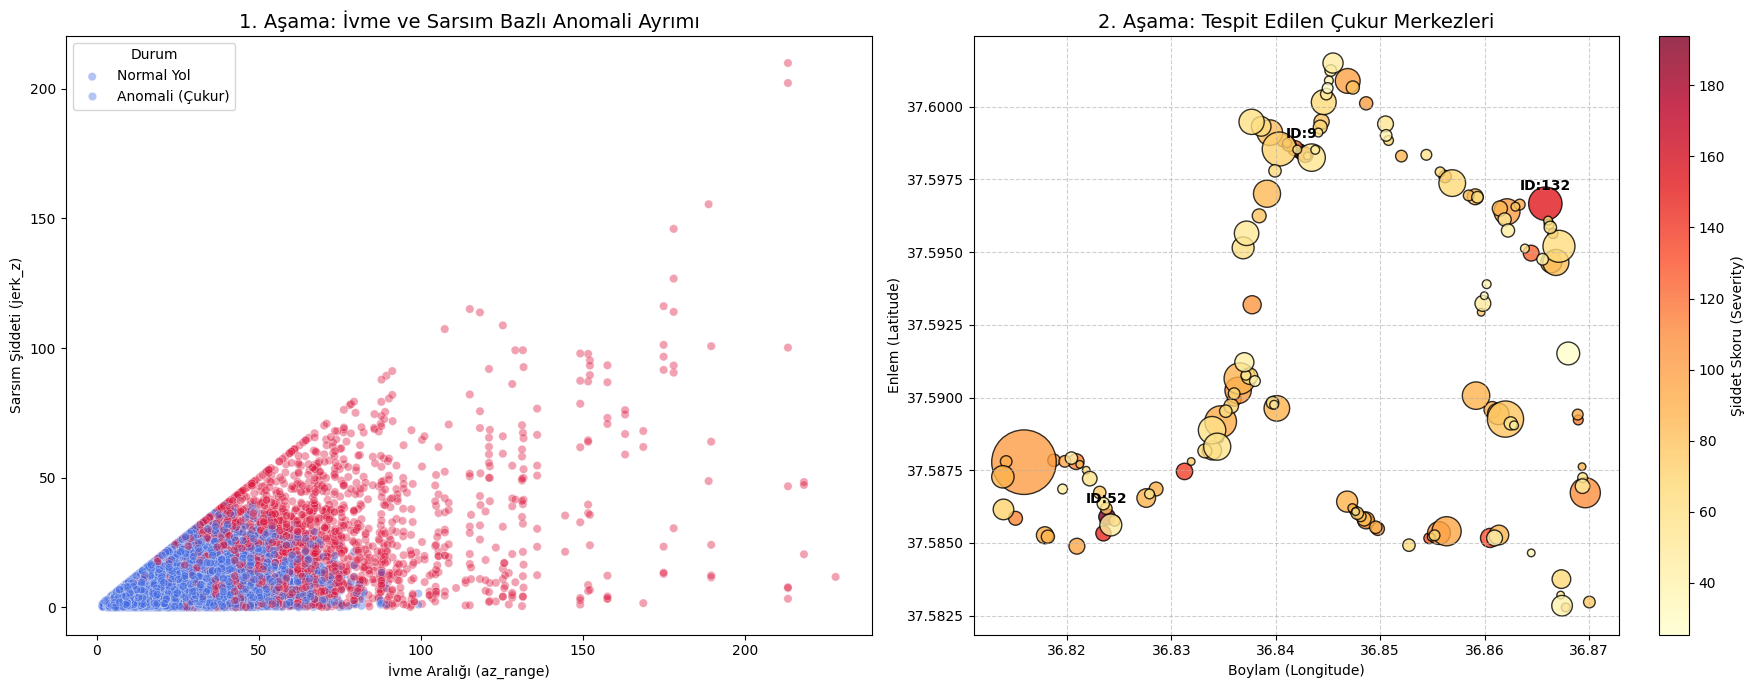

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-muted')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))


sns.scatterplot(
    data=df_moving,
    x='az_range',
    y='jerk_z',
    hue='is_anomaly',
    palette={0: 'royalblue', 1: 'crimson'},
    alpha=0.4,
    ax=ax1
)
ax1.set_title("1. Aşama: İvme ve Sarsım Bazlı Anomali Ayrımı", fontsize=14)
ax1.set_xlabel("İvme Aralığı (az_range)")
ax1.set_ylabel("Sarsım Şiddeti (jerk_z)")
ax1.legend(title="Durum", labels=['Normal Yol', 'Anomali (Çukur)'])

# ---------------------------------------------------------
# GRAFİK 2: Coğrafi Küme Merkezleri (Pothole Map)
# ---------------------------------------------------------
# Bu grafik GPS koordinatları üzerinde çukur merkezlerini ve şiddetini çizer
scatter = ax2.scatter(
    potholes_df['lon'],
    potholes_df['lat'],
    s=potholes_df['n_points'] * 10,  # Nokta sayısı ne kadar çoksa daire o kadar büyük
    c=potholes_df['severity_score'],
    cmap='YlOrRd',
    edgecolors='black',
    alpha=0.8
)

# En şiddetli 3 çukura ID etiketi ekleyelim
for i, row in potholes_df.head(3).iterrows():
    ax2.annotate(f"ID:{int(row['cluster_id'])}", (row['lon'], row['lat']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.colorbar(scatter, ax=ax2, label='Şiddet Skoru (Severity)')
ax2.set_title("2. Aşama: Tespit Edilen Çukur Merkezleri", fontsize=14)
ax2.set_xlabel("Boylam (Longitude)")
ax2.set_ylabel("Enlem (Latitude)")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()